In [846]:
import pandas as pd
import numpy as np

# Data Preparation

In [847]:
url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

data = pd.read_csv(url)
len(data)

7043

In [848]:
df = data.copy()

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [849]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [850]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [851]:
df.dtypes[df.dtypes == 'object'].index

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [852]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']
 
# Removing 'customerid', 'tenure', 'monthlycharges', 'totalcharges', and 'churn'
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [853]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [854]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [855]:
categorical_cols = list(df.dtypes[df.dtypes == 'object'].index)
categorical_cols

['customerid',
 'gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'totalcharges',
 'churn']

In [856]:
for col in categorical_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [857]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,no
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.5,no
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,yes
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,no
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,yes


In [858]:
nemerical_Cols = list(df.dtypes[df.dtypes != "object"].index)

In [859]:
nemerical_Cols

['seniorcitizen', 'tenure', 'monthlycharges']

In [860]:
# pd.to_numeric(df.totalcharges)

In [861]:
tc = pd.to_numeric(df.totalcharges, errors = "coerce")

In [862]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors = "coerce")

In [863]:
df.totalcharges

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: totalcharges, Length: 7043, dtype: float64

In [864]:
tc.isnull().sum()

11

In [865]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                object
dtype: object

In [866]:
df[tc.isnull()][["customerid", "totalcharges"]]

,customerid,totalcharges
488,4472-lvygi,NaN
753,3115-czmzd,NaN
936,5709-lvoeq,NaN
1082,4367-nuyao,NaN
1340,1371-dwpaz,NaN
3331,7644-omvmy,NaN
3826,3213-vvolg,NaN
4380,2520-sgtta,NaN
5218,2923-arzlg,NaN
6670,4075-wkniu,NaN


In [867]:
df.totalcharges.isnull().sum()

11

In [868]:
df.churn.unique()

array(['no', 'yes'], dtype=object)

In [869]:
df.totalcharges = df.totalcharges.fillna(0)

In [870]:
df.totalcharges.isnull().sum()

0

In [871]:
df.churn.unique()

array(['no', 'yes'], dtype=object)

we churn = 'yes' as '1'& churn = 'no' as 0

In [872]:
(df.churn == 'yes').astype(int).head(), df.churn.head()

(0    0
 1    0
 2    1
 3    0
 4    1
 Name: churn, dtype: int32,
 0     no
 1     no
 2    yes
 3     no
 4    yes
 Name: churn, dtype: object)

In [873]:
df.churn = (df.churn == 'yes').astype(int)

In [874]:
df.churn

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int32

In [875]:
from sklearn.model_selection import train_test_split

In [876]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [877]:
len(df_full_train), len(df_test)

(5634, 1409)

In [878]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val)

(4225, 1409)

In [879]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [880]:
len(df_train) + len(df_val) +len(df_test)

7043

In [881]:
df_full_train = df_full_train.reset_index(drop = True)
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [882]:
y_full_train = df_full_train.churn.values
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [883]:
y_train

array([0, 0, 1, ..., 1, 0, 1])

In [884]:
# del df_full_train['churn']
# del df_train['churn']
# del df_val['churn']
# del df_test['churn'] 

In [885]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [886]:
global_churn = df_full_train.churn.mean()
global_churn

0.26996805111821087

In [887]:
df.churn.unique()

array([0, 1])

In [888]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [889]:
df_full_train[numerical].nunique()

tenure              73
monthlycharges    1494
totalcharges      5291
dtype: int64

### exploring the feature importance: Churn rate and risk ratio

In [890]:
gender_rate = df_full_train.groupby('gender').churn.agg(['mean'])
gender_rate

,mean
gender,
female,0.276824
male,0.263214


In [891]:
female_rate = gender_rate['mean'].iloc[0]
male_rate = gender_rate['mean'].iloc[1]

In [892]:
female_rate - global_churn

0.006855983216553063

In [893]:
male_rate - global_churn

-0.006754520462819769

Here both categories of gender aren't likely important 

In [894]:
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group['diff'] = df_group['mean'] - global_churn
df_group['risk'] = df_group['mean'] / global_churn
df_group

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


In [895]:
from IPython.display import display

for col in categorical:
    df_group = df_full_train.groupby(col).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    print(col)
    display(df_group)


    print("\n")

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## relatively high value RR
- seniorcitizen : 1 (senior)
- internetservice : fiber_optic
- onlinesecurity : no
- techsupport : no
- contract : month-to-month
- paymentmethod : electronic_check

Values for this difference smaller than 0 indicate a higher likelihood to churn,
while values larger than 0 indicate a lower likelihood to churn.

As for the risk ratio, it is obtained by dividing the group’s churn rate by the global churn rate. 
Values greater than 1 suggest a higher likelihood to churn, whereas values less than 1 suggest a lower likelihood to churn.

# Feature importance
> Measuring the categorical features importance using "Mutual Infomration" method

In [896]:
from sklearn.metrics import mutual_info_score


for col in categorical:
    result = mutual_info_score(df_full_train.churn, df_full_train[col])

    print(col, result)

gender 0.0001174846211139946
seniorcitizen 0.009410216144208144
partner 0.009967689095399745
dependents 0.012345815445534689
phoneservice 0.00022871269738296285
multiplelines 0.0008574478744731856
internetservice 0.055867945893496467
onlinesecurity 0.06308524972985574
onlinebackup 0.0469234640537918
deviceprotection 0.04345286925268559
techsupport 0.06103245991777444
streamingtv 0.03185333110086085
streamingmovies 0.03158089669519908
contract 0.0983203874041556
paperlessbilling 0.01758882715925275
paymentmethod 0.043210027531582915


In [897]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)
 
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi

gender              0.000117
seniorcitizen       0.009410
partner             0.009968
dependents          0.012346
phoneservice        0.000229
multiplelines       0.000857
internetservice     0.055868
onlinesecurity      0.063085
onlinebackup        0.046923
deviceprotection    0.043453
techsupport         0.061032
streamingtv         0.031853
streamingmovies     0.031581
contract            0.098320
paperlessbilling    0.017589
paymentmethod       0.043210
dtype: float64

In [898]:
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

### Measuring the numerical features importance by getting the Correlation

- A negative correlation (r = -1) indicates a strong inverse relationship, where one variable increases as the other decreases.
- A positive correlation (r = 1) indicates a strong positive relationship, where both variables increase together.
- An r value close to 0 suggests a weak or no linear relationship between the variables.

 ### The strength of the correlation is indicated by the absolute value of r:

- 0.0 < |r| < 0.2: Low correlation
- 0.2 < |r| < 0.5: Moderate correlation
- 0.6 < |r| < 1.0: Strong correlation

In [899]:
df_full_train[numerical].corrwith(df_full_train.churn)


tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [900]:
df_full_train[numerical].corrwith(df_full_train.churn).abs().sort_values(ascending=False)

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

In [901]:
temp_dict = df_train[['gender', 'contract']].iloc[:20].to_dict(orient='records')

In [902]:
temp_dict

[{'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'one_year'},
 {'gender': 'male', 'contract': 'two_year'}]

In [903]:
df_train.contract.unique()

array(['two_year', 'month-to-month', 'one_year'], dtype=object)

In [904]:
unique_contracts = set(d["contract"] for d in temp_dict)
unique_contracts

{'month-to-month', 'one_year', 'two_year'}

In [905]:
# A sparse matrix is a memory-efficient way of encoding data when there are many zeros in the dataset. 
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer(sparse=False)
dv.fit(temp_dict)
 
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'gender=female', 'gender=male'], dtype=object)

In [906]:
dv.transform(temp_dict)

array([[0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 0., 1., 0., 1.]])

In [907]:
temp_dict[0]

{'gender': 'female', 'contract': 'two_year'}

In [908]:
del df_train['churn']
del df_val['churn']
del df_test['churn'] 

In [909]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')
train_dict[0]

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'yes',
 'techsupport': 'yes',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [910]:
dv_v = DictVectorizer(sparse=False)

# The DictVectorizer learns what features (keys and possible categorical values) exist in the data.
dv_v.fit(train_dict)

dv_v.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [911]:
X_train = dv_v.transform(train_dict)

In [912]:
X_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.20000e+01, 8.42515e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+01, 1.02155e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.00000e+00, 4.13650e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        2.00000e+00, 1.90050e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        2.70000e+01, 7.61950e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        9.00000e+00, 7.51650e+02]])

In [913]:
X_train[0]

array([0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00,
       0.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00,
       0.00000e+00, 1.00000e+00, 0.00000e+00, 1.15500e+02, 0.00000e+00,
       0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
       0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00,
       0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
       0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
       0.00000e+00, 0.00000e+00, 1.00000e+00, 7.20000e+01, 8.42515e+03])

In [914]:
X_train.shape

(4225, 45)

In [915]:
unique_values_of_all_features = 0
for col in categorical:
    unique_values_of_all_features += df[col].nunique()    
unique_values_of_all_features

43

>When dealing with validation data, we can reuse the same DictVectorizer instance that we created before. Instead of using the fit function followed by the transform function, we only need to apply the transform function to the validation data. This ensures that the transformation process applied to the validation data is consistent with the encoding used for the training data.
>
> the vectorizer uses the same mapping it learned from training to convert validation data into numeric form.

> If validation_data contains unseen categories, those are simply ignored (or represented as zeros), but the order and meaning of columns remain identical to the training data.

In [916]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv_v.transform(val_dicts)
X_val

array([[0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 1.0000e+00, 7.1000e+01,
        4.9734e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.0750e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.0350e+01],
       ...,
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 1.8000e+01,
        1.0581e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        9.3300e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 3.0000e+00,
        2.9285e+02]])

# Logistic Regression

> In binary classification, the target variable yiyi​ belongs to one of two classes: 0 or 1. These classes are often referred to as “negative” and “positive,” and they represent two mutually exclusive outcomes. In the context of churn prediction, “no churn” and “churn” are examples of binary classes. Similarly, in email classification, “no spam” and “spam” are also binary classes.

> That means g(xi) outputs a number from 0 to 1 that we can treat as the probability of xi belonging to the positive class.

> Formula:
> - Linear regression: g(xi)=w0+wTxi → outputs a number −∞..∞∈R

> - x0 – bias term
> - wT – weights vector
> - xi​ – features
> Logistic regression: g(xi)=SIGMOID(w0+wTxi) → outputs a number 0..1∈R

> - sigmoid(z)= 1 / (1+exp(−z))

In [917]:
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [918]:
x = np.linspace(-7, 7, 51)

In [919]:
result = sigmoid(x)

In [920]:
result

array([9.11051194e-04, 1.20508423e-03, 1.59386223e-03, 2.10780106e-03,
       2.78699622e-03, 3.68423990e-03, 4.86893124e-03, 6.43210847e-03,
       8.49286285e-03, 1.12064063e-02, 1.47740317e-02, 1.94550846e-02,
       2.55807883e-02, 3.35692233e-02, 4.39398154e-02, 5.73241759e-02,
       7.44679452e-02, 9.62155417e-02, 1.23467048e-01, 1.57095469e-01,
       1.97816111e-01, 2.46011284e-01, 3.01534784e-01, 3.63547460e-01,
       4.30453776e-01, 5.00000000e-01, 5.69546224e-01, 6.36452540e-01,
       6.98465216e-01, 7.53988716e-01, 8.02183889e-01, 8.42904531e-01,
       8.76532952e-01, 9.03784458e-01, 9.25532055e-01, 9.42675824e-01,
       9.56060185e-01, 9.66430777e-01, 9.74419212e-01, 9.80544915e-01,
       9.85225968e-01, 9.88793594e-01, 9.91507137e-01, 9.93567892e-01,
       9.95131069e-01, 9.96315760e-01, 9.97213004e-01, 9.97892199e-01,
       9.98406138e-01, 9.98794916e-01, 9.99088949e-01])

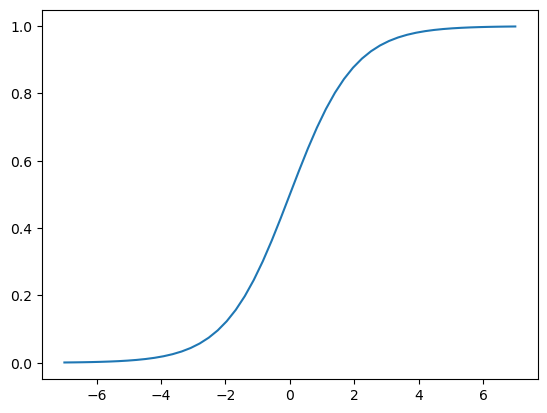

In [921]:
plt.plot(x, sigmoid(x))

In [922]:
np.unique(y_train)

array([0, 1])

In [923]:
from sklearn.linear_model import LogisticRegression
 
model = LogisticRegression()
model.fit(X_train, y_train)

D:\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [924]:
model.coef_[0]

array([ 4.74613189e-01, -1.74834822e-01, -4.07487023e-01, -2.97361562e-02,
       -7.79724995e-02,  6.26942018e-02, -8.90408337e-02, -8.13620237e-02,
       -3.43214810e-02, -7.33871747e-02, -3.35110640e-01,  3.16442818e-01,
       -8.90408337e-02,  3.68097061e-03, -2.58154682e-01,  1.41435345e-01,
        9.01068152e-03,  6.25400319e-02, -8.90408337e-02, -8.12078538e-02,
        2.65542674e-01, -8.90408337e-02, -2.84210496e-01, -2.31195036e-01,
        1.23486381e-01, -1.66047618e-01,  5.83389626e-02, -8.69911118e-02,
       -3.20490312e-02,  7.04599160e-02, -5.91284287e-02,  1.41435345e-01,
       -2.49144000e-01,  2.15427749e-01, -1.20311964e-01, -8.90408337e-02,
        1.01644142e-01, -7.08518550e-02, -8.90408337e-02,  5.21840331e-02,
        2.13343815e-01, -8.90408337e-02, -2.32011637e-01, -7.03695313e-02,
        3.81881557e-04])

In [925]:
model.intercept_
model.intercept_[0]

-0.1090634700754041

In [926]:
training_result = model.predict(X_train)

In [927]:
model.predict_proba(X_train)

array([[0.90458654, 0.09541346],
       [0.32065317, 0.67934683],
       [0.36628428, 0.63371572],
       ...,
       [0.46827884, 0.53172116],
       [0.95744532, 0.04255468],
       [0.30126582, 0.69873418]])

In [928]:
training_chrun_decision = (model.predict_proba(X_train)[:, 1] > 0.5)
((training_chrun_decision.astype(int)) == y_train).mean()

0.805207100591716

In [929]:
(training_result == y_train).mean()

0.805207100591716

In [930]:
y_pred = model.predict_proba(X_val)[:,1]
y_pred

array([0.0090045 , 0.20443038, 0.21211564, ..., 0.13644659, 0.7997995 ,
       0.83742463])

In [931]:
((y_pred > 0.5) == y_val).mean()

0.8034066713981547

In [932]:
churn_decision = y_pred >0.5
churn_decision

array([False, False, False, ..., False,  True,  True])

In [933]:
df_val[churn_decision].customerid.shape

(311,)

In [934]:
dv_v.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [935]:
model.coef_[0]

array([ 4.74613189e-01, -1.74834822e-01, -4.07487023e-01, -2.97361562e-02,
       -7.79724995e-02,  6.26942018e-02, -8.90408337e-02, -8.13620237e-02,
       -3.43214810e-02, -7.33871747e-02, -3.35110640e-01,  3.16442818e-01,
       -8.90408337e-02,  3.68097061e-03, -2.58154682e-01,  1.41435345e-01,
        9.01068152e-03,  6.25400319e-02, -8.90408337e-02, -8.12078538e-02,
        2.65542674e-01, -8.90408337e-02, -2.84210496e-01, -2.31195036e-01,
        1.23486381e-01, -1.66047618e-01,  5.83389626e-02, -8.69911118e-02,
       -3.20490312e-02,  7.04599160e-02, -5.91284287e-02,  1.41435345e-01,
       -2.49144000e-01,  2.15427749e-01, -1.20311964e-01, -8.90408337e-02,
        1.01644142e-01, -7.08518550e-02, -8.90408337e-02,  5.21840331e-02,
        2.13343815e-01, -8.90408337e-02, -2.32011637e-01, -7.03695313e-02,
        3.81881557e-04])

In [936]:
data = dict(zip(dv_v.get_feature_names_out(), model.coef_[0].round(3)))

In [937]:
sorted_dict = dict(sorted(data.items(), key=lambda item: item[1], reverse=True))

print(sorted_dict)

{'contract=month-to-month': 0.475, 'internetservice=fiber_optic': 0.316, 'onlinesecurity=no': 0.266, 'seniorcitizen': 0.215, 'techsupport=no': 0.213, 'multiplelines=no_phone_service': 0.141, 'phoneservice=no': 0.141, 'paperlessbilling=yes': 0.123, 'streamingmovies=yes': 0.102, 'paymentmethod=electronic_check': 0.07, 'deviceprotection=no': 0.063, 'onlinebackup=no': 0.063, 'partner=yes': 0.058, 'streamingtv=yes': 0.052, 'multiplelines=yes': 0.009, 'monthlycharges': 0.004, 'totalcharges': 0.0, 'dependents=no': -0.03, 'paymentmethod=credit_card_(automatic)': -0.032, 'gender=female': -0.034, 'paymentmethod=mailed_check': -0.059, 'tenure': -0.07, 'streamingtv=no': -0.071, 'gender=male': -0.073, 'dependents=yes': -0.078, 'deviceprotection=yes': -0.081, 'onlinebackup=yes': -0.081, 'paymentmethod=bank_transfer_(automatic)': -0.087, 'deviceprotection=no_internet_service': -0.089, 'internetservice=no': -0.089, 'onlinebackup=no_internet_service': -0.089, 'onlinesecurity=no_internet_service': -0.08

In [938]:
top_5 = dict(list(sorted_dict.items())[:5])

In [939]:
top_5

{'contract=month-to-month': 0.475,
 'internetservice=fiber_optic': 0.316,
 'onlinesecurity=no': 0.266,
 'seniorcitizen': 0.215,
 'techsupport=no': 0.213}

In [940]:
least_important_feature = dict(list(sorted_dict.items())[-1:])
least_important_feature

{'contract=two_year': -0.407}

# Using the model

In [941]:
full_data_dict = df_full_train[categorical + numerical].to_dict(orient='records')
test_dict = df_test[categorical + numerical].to_dict(orient='records')

In [942]:
dv_full = DictVectorizer(sparse=False)

dv_full.fit(full_data_dict)

X_full = dv_full.transform(full_data_dict)

In [943]:
dv_full.get_feature_names_out().shape

(45,)

In [944]:
X_test = dv_full.transform(test_dict)

In [945]:
full_model = LogisticRegression()

full_model.fit(X_full, y_full_train)

D:\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [946]:
full_training_prediction = model.predict(X_full)

In [947]:
(full_training_prediction == y_full_train).astype(int).mean()

0.8047568335108272

In [948]:
y_test_prediction = model.predict(X_test)

In [949]:
(y_test_prediction == y_test).astype(int).mean()

0.808374733853797

# Model Evaluation

## 1. Accuracy
> it doesn’t always provide the full picture of a model’s performance, especially in cases with imbalanced datasets or when specific types of errors are more critical than others.

In [950]:
thresholds = np.linspace(0, 1, 21)
thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [951]:
scores = {}

for t in thresholds:
    churn_prediction = (y_pred >= t).astype(int)

    score = (y_val == churn_prediction).mean()

    scores[t] = score

    print(f"Threshold: {t}, Score = {round(score, 4)}")

Threshold: 0.0, Score = 0.274
Threshold: 0.05, Score = 0.5089
Threshold: 0.1, Score = 0.5912
Threshold: 0.15000000000000002, Score = 0.6664
Threshold: 0.2, Score = 0.7097
Threshold: 0.25, Score = 0.7388
Threshold: 0.30000000000000004, Score = 0.7601
Threshold: 0.35000000000000003, Score = 0.7722
Threshold: 0.4, Score = 0.785
Threshold: 0.45, Score = 0.7928
Threshold: 0.5, Score = 0.8034
Threshold: 0.55, Score = 0.8013
Threshold: 0.6000000000000001, Score = 0.7949
Threshold: 0.65, Score = 0.7864
Threshold: 0.7000000000000001, Score = 0.7658
Threshold: 0.75, Score = 0.7445
Threshold: 0.8, Score = 0.7346
Threshold: 0.8500000000000001, Score = 0.726
Threshold: 0.9, Score = 0.726
Threshold: 0.9500000000000001, Score = 0.726
Threshold: 1.0, Score = 0.726


In [952]:
max(scores, key=scores.get)

0.5

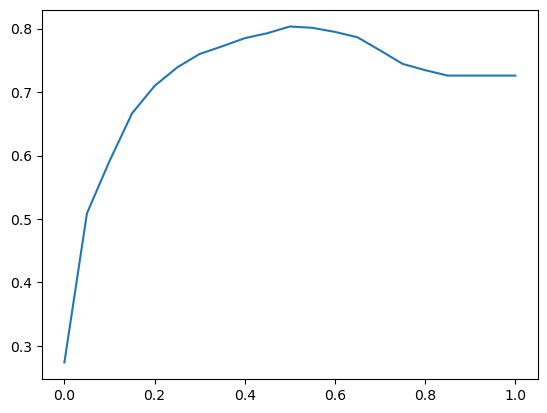

In [953]:
plt.plot(list(scores.keys()),list(scores.values()))

### Scikit-Learn build-in accuracy function

In [954]:
from sklearn.metrics import accuracy_score

scores_built_in_func = {}
 
for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    
    print('%.2f %.3f' % (t, score))
    scores_built_in_func[t] = score

0.00 0.274
0.05 0.509
0.10 0.591
0.15 0.666
0.20 0.710
0.25 0.739
0.30 0.760
0.35 0.772
0.40 0.785
0.45 0.793
0.50 0.803
0.55 0.801
0.60 0.795
0.65 0.786
0.70 0.766
0.75 0.744
0.80 0.735
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


In [955]:
max(scores_built_in_func, key=scores_built_in_func.get)

0.5

In [956]:
# predicts all customers as not churning
from collections import Counter
 
Counter(y_pred >= 1.0)

Counter({False: 1409})

In [957]:
# 1023: actual non-churning, 386: actual churning
Counter(y_val)

Counter({0: 1023, 1: 386})

In [958]:
# The accuracy of assuming every cuatomer is non-churning

1023/1409

0.7260468417317246

-  Even when assuming all customers are cmom-churning the accuracy is 72%.
- meaning that the dataset is inbalances, so the accuracy isn't the right metric to use to eevaluate the model.

In [959]:
# precentage of non-churning
1 - y_val.mean()

0.7260468417317246

- We can observe that there are significantly more non-churning customers than churning ones, with only 27% being churning customers and 73% being non-churning customers. This situation highlights a common challenge known as class imbalance, where one class has far more samples than the other.

- In cases of class imbalance, the traditional accuracy metric can be misleading. For example, a dummy model that predicts the majority class for all samples can achieve a high accuracy simply by getting most of the samples right for the majority class. However, it will perform poorly in identifying the minority class (in this case, the churning customers), which is often more crucial to predict accurately.

- To effectively address class imbalance and evaluate our model, we should consider alternative metrics such as:

1. Precision: This metric measures the proportion of true positive predictions among all positive predictions. It is particularly useful when the cost of false positives is high.
2. Recall: Recall measures the proportion of true positive predictions among all actual positive instances. It is valuable when the cost of false negatives is significant.
3. F1-Score: The F1-Score is the harmonic mean of precision and recall, providing a balanced measure that considers both false positives and false negatives.
4. Area Under the Receiver Operating Characteristic Curve (AUC-ROC): The ROC curve plots the true positive rate against the false positive rate at various threshold settings. The AUC-ROC score assesses the classifier’s ability to distinguish between the positive and negative classes, making it particularly useful for imbalanced datasets.

### 2. Confusion table: 
is a way of measuring different types of errors and correct decisions that binary classifiers can make. Considering this information, it is possible to evaluate the quality of the model by different strategies.

When comes to a prediction of an LR model, each falls into one of four different categories:

1. Prediction is that the customer WILL churn. This is known as the Positive class
> - And Customer actually churned - Known as a True Positive (TP)
> - But Customer actually did not churn - Known as a False Positive (FP)
2. Prediction is that the customer WILL NOT churn' - This is known as the Negative class
> - Customer did not churn - True Negative (TN)
> - Customer churned - False Negative (FN)

In [960]:
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

TP = (predict_positive & actual_positive).sum()
FP = (predict_positive & actual_negative).sum()

TN = (predict_negative & actual_negative).sum()
FN = (predict_negative & actual_positive).sum()

In [961]:
TP, FP, TN, FN

(210, 101, 922, 176)

In [962]:
confusion_mat = np.array([
    [TP, FN],
    [FP, TN]
])
confusion_mat

array([[210, 176],
       [101, 922]])

In [963]:
tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()
 
fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

In [964]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
 
confusion_matrix

array([[922, 101],
       [176, 210]])

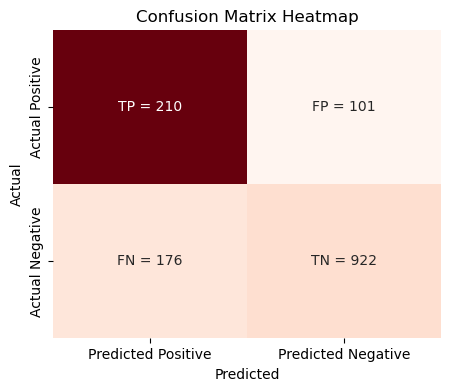

In [965]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


labels = np.array([[f"TP = {tp}", f"FP = {fp}"],
                   [f"FN = {fn}", f"TN = {tn}"]])

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix, annot=labels, fmt="", cmap="Reds", cbar=False,
            xticklabels=["Predicted Positive", "Predicted Negative"],
            yticklabels=["Actual Positive", "Actual Negative"])

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### 1. Precision

**Precision** focuses on the quality of the model’s positive predictions.  
It tells us how many of the "positive" predictions were actually correct.  

It is important in situations where **false positives** need to be minimized —  
such as detecting **spam emails** or **fraud**.

The formula for precision is:

\[
\text{Precision} = \frac{TP}{TP + FP}
\]

where:  
- **TP** = True Positives  
- **FP** = False Positives  

- **Predicted Positives** = TP + FP
---

### 2. Recall

**Recall** measures how good the model is at identifying positive cases.  
It shows the proportion of true positives detected out of all actual positive instances.  

High recall is essential when **missing positive cases** has significant consequences —  
for example, in **medical diagnosis** or **fraud detection**.

The formula for recall is:

\[
\text{Recall} = \frac{TP}{TP + FN}
\]

where:  
- **TP** = True Positives  
- **FN** = False Negatives

- **Real Positives** = TP + FN

 - Precision : From the predicted positives, how many we predicted right. See how the word precision is similar to the word prediction?

 - Recall : From the real positives, how many we predicted right. See how the word recall is similar to the word real?

In [966]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

In [967]:
accuracy = (tp + tn) / (tp + tn + fp + fn)

precision = tp / (tp + fp)

recall = tp / (tp + fn)

In [968]:
# fraction of false predicted positives(people who were predicted as churning but they are not really churning.
# Loss of sending offer emails to people who aren't really churning
# promotional email goes to 311 people, but 210 are actually going to churn (--> 33% are mistakes)
1 - precision, tp + fp, tp

(0.3247588424437299, 311, 210)

In [969]:
# fraction of false predicted positives(people who were predicted as non-churning but they are really churning.
# Loss of customers who didn't recive an offer email (176 customers weres supposed to recieve emails)
# 386 were supposed to reveive emails but only 210 of them who actually received
1 - recall, tp + fn, fn

(0.4559585492227979, 386, 176)

### 3. ROC Curve (Receiver Operating Characteristics)

In [970]:
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

In [971]:
tpr, fpr

(0.5440414507772021, 0.09872922776148582)

### over different thresholds

In [972]:
scores = []

threshols = np.linspace(0, 1, 101)

actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

for t in thresholds:
    predicted_positive = (y_pred >= t)
    predicted_negative = (y_pred < t)

    tp = (predicted_positive & actual_positive).sum()
    fp = (predicted_positive & actual_negative).sum()

    fn = (predicted_negative & actual_positive).sum()
    tn = (predicted_negative & actual_negative).sum()

    scores.append((t, tp, tn, fp, fn))

In [973]:
columns = ['threshold', 'tp', 'tn', 'fp', 'fn']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,threshold,tp,tn,fp,fn
0,0.00,386,0,1023,0
1,0.05,379,338,685,7
2,0.10,366,467,556,20
3,0.15,351,588,435,35
4,0.20,333,667,356,53
5,0.25,309,732,291,77
6,0.30,284,787,236,102
7,0.35,272,816,207,114
8,0.40,249,857,166,137
9,0.45,229,888,135,157


In [974]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
df_scores[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,386,0,1023,0,1.000000,1.000000
10,0.5,210,922,101,176,0.544041,0.098729
20,1.0,0,1023,0,386,0.000000,0.000000


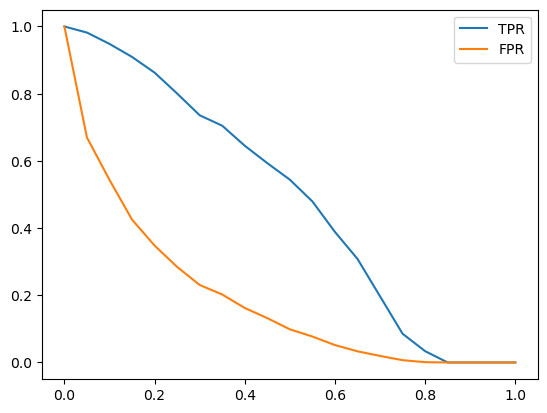

In [975]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
plt.legend()

In [976]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []
    thresholds = np.linspace(0, 1, 101)
 
    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
 
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)
 
        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
 
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
 
        scores.append((t, tp, tn, fp, fn))
 
    columns = ['threshold', 'tp', 'tn', 'fp', 'fn']
    df_scores = pd.DataFrame(scores, columns=columns)
 
    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
 
    return df_scores

### Random Model

In [977]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))

In [978]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)
df_rand[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,386,0,1023,0,1.000000,1.000000
10,0.1,347,100,923,39,0.898964,0.902248
20,0.2,307,201,822,79,0.795337,0.803519
30,0.3,276,299,724,110,0.715026,0.707722
40,0.4,237,399,624,149,0.613990,0.609971
50,0.5,202,505,518,184,0.523316,0.506354
60,0.6,161,614,409,225,0.417098,0.399804
70,0.7,121,721,302,265,0.313472,0.295210
80,0.8,78,817,206,308,0.202073,0.201369
90,0.9,40,922,101,346,0.103627,0.098729


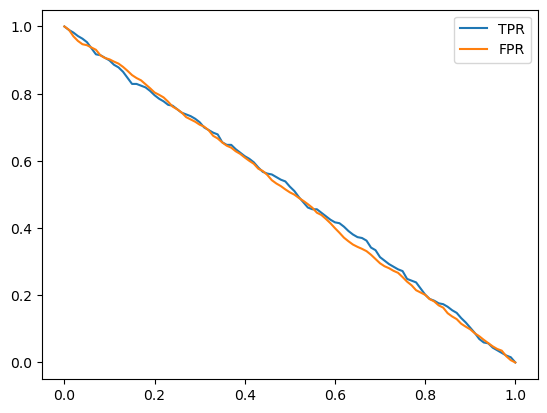

In [979]:
plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')
plt.legend()

### Ideal Model

In [980]:
num_pos = (y_val == 1).sum()
num_neg = (y_val == 0).sum()

In [981]:
y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1])

In [982]:
y_ideal_pred = np.linspace(0, 1, len(y_ideal))
y_ideal_pred

array([0.00000000e+00, 7.10227273e-04, 1.42045455e-03, ...,
       9.98579545e-01, 9.99289773e-01, 1.00000000e+00])

In [983]:
1 - y_val.mean()

0.7260468417317246

In [984]:
accuracy_ideal = ((y_ideal_pred >= 0.726) == y_ideal).mean()
accuracy_ideal

1.0

In [985]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,386,0,1023,0,1.000000,1.000000
10,0.1,386,141,882,0,1.000000,0.862170
20,0.2,386,282,741,0,1.000000,0.724340
30,0.3,386,423,600,0,1.000000,0.586510
40,0.4,386,564,459,0,1.000000,0.448680
50,0.5,386,704,319,0,1.000000,0.311828
60,0.6,386,845,178,0,1.000000,0.173998
70,0.7,386,986,37,0,1.000000,0.036168
80,0.8,282,1023,0,104,0.730570,0.000000
90,0.9,141,1023,0,245,0.365285,0.000000


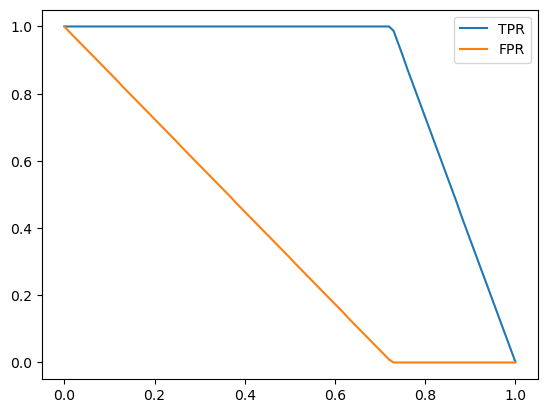

In [986]:
plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR')
plt.legend()

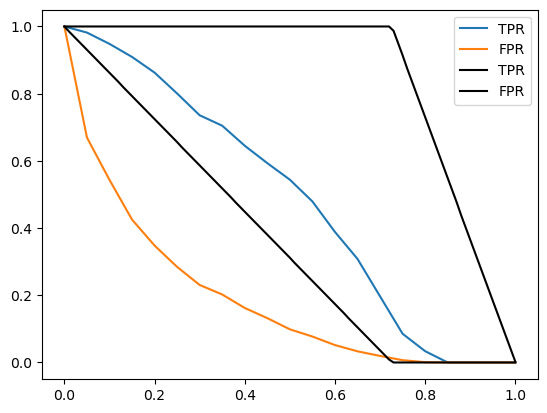

In [987]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
 
#plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
#plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')
 
plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR', color = 'black')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR', color = 'black')
 
plt.legend()

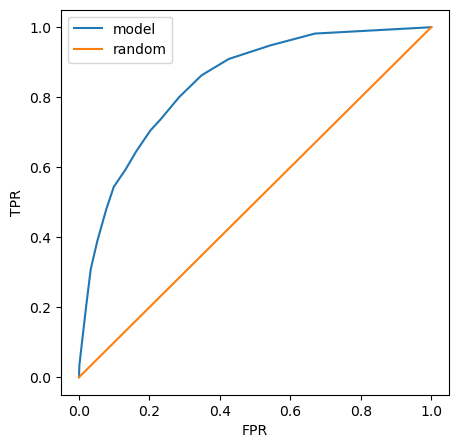

In [988]:
plt.figure(figsize=(5,5))
 
plt.plot(df_scores.fpr, df_scores.tpr, label='model')
plt.plot([0,1], [0,1], label='random')
#plt.plot(df_rand.fpr, df_rand.tpr, label='random')
#plt.plot(df_ideal.fpr, df_ideal.tpr, label='ideal')
 
plt.xlabel('FPR')
plt.ylabel('TPR')
 
plt.legend()

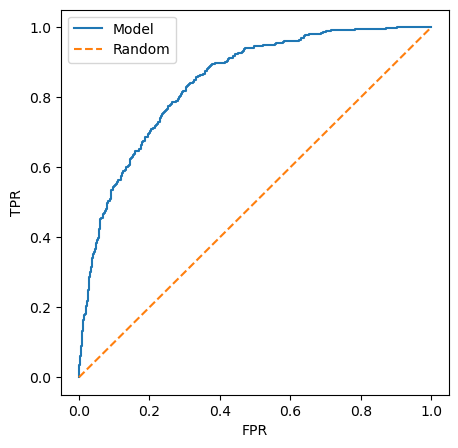

In [989]:
# We can also use the ROC functionality of scikit learn package
from sklearn.metrics import roc_curve
 
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
 
plt.figure(figsize=(5,5))
 
plt.plot(fpr, tpr, label='Model')
plt.plot([0,1], [0,1], label='Random', linestyle='--')
 
plt.xlabel('FPR')
plt.ylabel('TPR')
 
plt.legend()

### ROC AUC – Area under the ROC curve

In [990]:
from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(y_val, y_pred)

auc(fpr, tpr)

0.8438429084426076

In [991]:
# There is a shortcut in scikit-learn package

from sklearn.metrics import roc_auc_score
 
roc_auc_score(y_val, y_pred)

0.8438429084426076

## Cross-Validation

In [1010]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C,solver='liblinear', max_iter=100000)
    model.fit(X_train, y_train)
    
    return dv, model

def predict(df_val, dv, model):

    dicts = df_val[categorical + numerical].to_dict(orient='records')
    X_val = dv.transform(dicts)

    y_pred = model.predict_proba(X_val)[:, 1]

    return y_pred

In [1011]:
from sklearn.model_selection import KFold

In [1012]:
from tqdm.auto import tqdm

In [1013]:
n_splits = 5

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/7 [00:00<?, ?it/s]

C=0.001 0.825 +- 0.013
C=0.01 0.839 +- 0.009
C=0.1 0.841 +- 0.007
C=0.5 0.841 +- 0.007
C=1 0.841 +- 0.007
C=5 0.841 +- 0.008
C=10 0.841 +- 0.007


In [1004]:
scores

[0.8438782959549732,
 0.8447494537147399,
 0.8336463977523579,
 0.8348168606510199,
 0.8520284898497066]